# Bloque 3 — Análisis Exploratorio + Experimentación

**Prueba Técnica · Data Analyst · Cadena de Retail Multiformato · Centroamérica**

Este notebook tiene dos partes:

**Parte A — Análisis Exploratorio (5 preguntas)**
1. Estacionalidad del GMV semanal por formato
2. Pareto de categorías por formato
3. Cohortes de lealtad — retención y ticket
4. Quiebres de stock y su impacto
5. Hallazgo libre: concentración geográfica

**Parte B — Interpretación del A/B Test**
1. Validación del diseño experimental
2. Resultado en GMV (t-test con scipy)
3. Resultado en ticket y frecuencia
4. Decisión de negocio


## 0. Setup e Importaciones

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

DATA_PATH  = './Datasets/'
VIZ_PATH   = './bloque3_visualizaciones/'
os.makedirs(VIZ_PATH, exist_ok=True)

# Cargar datos pre-computados (por eficiencia — ver compute_results.py)
with open('./results.json', encoding='utf-8') as f:
    R = json.load(f)

print('Setup OK')
print(f"Dataset: {R['summary']['date_range']}")
print(f"Total GMV: ${R['summary']['total_gmv']:,.2f}")
print(f"Transacciones: {R['summary']['total_transactions']:,}")


Setup OK
Dataset: 2024-01-01 to 2025-06-30
Total GMV: $47,740,302.93
Transacciones: 171,324


## Carga de Datos

In [2]:
# Cargamos los datasets con los tipos ya corregidos (ver Bloque 0)
tx = pd.read_csv(DATA_PATH + 'transactions.csv')
ti = pd.read_csv(DATA_PATH + 'transaction_items.csv')
st = pd.read_csv(DATA_PATH + 'stores.csv')
pr = pd.read_csv(DATA_PATH + 'products.csv')
ve = pd.read_csv(DATA_PATH + 'vendors.csv')
sp = pd.read_csv(DATA_PATH + 'store_promotions.csv')

tx['transaction_date'] = pd.to_datetime(tx['transaction_date'])
st['opening_date']     = pd.to_datetime(st['opening_date'])
sp['start_date']       = pd.to_datetime(sp['start_date'])
sp['end_date']         = pd.to_datetime(sp['end_date'])
for c in ['transaction_id','customer_id','store_id']:
    tx[c] = tx[c].astype('string')
for c in ['transaction_item_id','transaction_id','item_id']:
    ti[c] = ti[c].astype('string')

# Base filtrada: solo COMPLETED con monto válido (decisión del Bloque 0)
tx_c = tx[(tx['status'] == 'COMPLETED') & (tx['total_amount'] > 0)].copy()
tx_s = tx_c.merge(st[['store_id','store_name','format','country','region','size_sqm',
                        'opening_date']], on='store_id', how='left')

print(f'Transacciones base (COMPLETED): {len(tx_c):,}')
print(f'Rango: {tx_c.transaction_date.min().date()} → {tx_c.transaction_date.max().date()}')


Transacciones base (COMPLETED): 171,324
Rango: 2024-01-01 → 2025-06-30


---
# PARTE A — Análisis Exploratorio


## A.1 — Estacionalidad por Formato

> ¿Cómo evoluciona el GMV semanal por formato de tienda?
> ¿Qué formato es más sensible a la estacionalidad?
> Identifica los 3 picos y las 3 caídas más significativas del período.


In [3]:
# GMV semanal por formato usando isocalendar (compatible con pandas 3.x)
tx_s_w = (
    tx_s
    .assign(
        year=lambda df: df['transaction_date'].dt.isocalendar().year.astype(int),
        week=lambda df: df['transaction_date'].dt.isocalendar().week.astype(int)
    )
    .assign(year_week=lambda df: df['year'].astype(str) + '-W' +
                                  df['week'].astype(str).str.zfill(2))
    .groupby(['year_week','format'], as_index=False)
    .agg(gmv=('total_amount','sum'))
)

# Total semanal (suma de todos los formatos)
weekly_total = tx_s_w.groupby('year_week')['gmv'].sum().reset_index()
weekly_total = weekly_total.sort_values('year_week').reset_index(drop=True)

print(f'Semanas en el dataset: {weekly_total.year_week.nunique()}')
print(f'GMV semanal promedio: ${weekly_total.gmv.mean():,.0f}')
print(f'GMV semanal máximo:   ${weekly_total.gmv.max():,.0f}')
print(f'GMV semanal mínimo:   ${weekly_total.gmv.min():,.0f}')


Semanas en el dataset: 79
GMV semanal promedio: $604,308
GMV semanal máximo:   $860,665
GMV semanal mínimo:   $87,108


In [4]:
# Variabilidad por formato (CV = std/mean)
variabilidad = (
    tx_s_w.groupby('format')['gmv']
    .agg(media='mean', std='std')
    .assign(cv=lambda df: df['std'] / df['media'] * 100)
    .sort_values('cv', ascending=False)
)
print('Coeficiente de Variación (CV) por formato:')
print('Mayor CV = más sensible a la estacionalidad')
print()
display(variabilidad.round(2))


Coeficiente de Variación (CV) por formato:
Mayor CV = más sensible a la estacionalidad



,media,std,cv
format,,,
EXPRESS,"27,684.15","6,756.35",24.41
DESCUENTO,"113,876.26","18,806.09",16.51
SUPERMERCADO,"230,815.11","35,574.48",15.41
HIPERMERCADO,"231,932.11","35,303.79",15.22


In [5]:
# Detectar top 3 picos y top 3 caídas en el GMV total semanal
weekly_sorted_asc  = weekly_total.nsmallest(3, 'gmv')
weekly_sorted_desc = weekly_total.nlargest(3, 'gmv')

print('Top 3 PICOS (mayor GMV semanal):')
for _, row in weekly_sorted_desc.iterrows():
    print(f'  {row.year_week}: ${row.gmv:>12,.0f}')

print()
print('Top 3 CAIDAS (menor GMV semanal):')
for _, row in weekly_sorted_asc.iterrows():
    print(f'  {row.year_week}: ${row.gmv:>12,.0f}')


Top 3 PICOS (mayor GMV semanal):
  2024-W51: $     860,665
  2024-W50: $     831,671
  2024-W49: $     819,352

Top 3 CAIDAS (menor GMV semanal):
  2025-W27: $      87,108
  2024-W07: $     485,346
  2024-W06: $     504,522


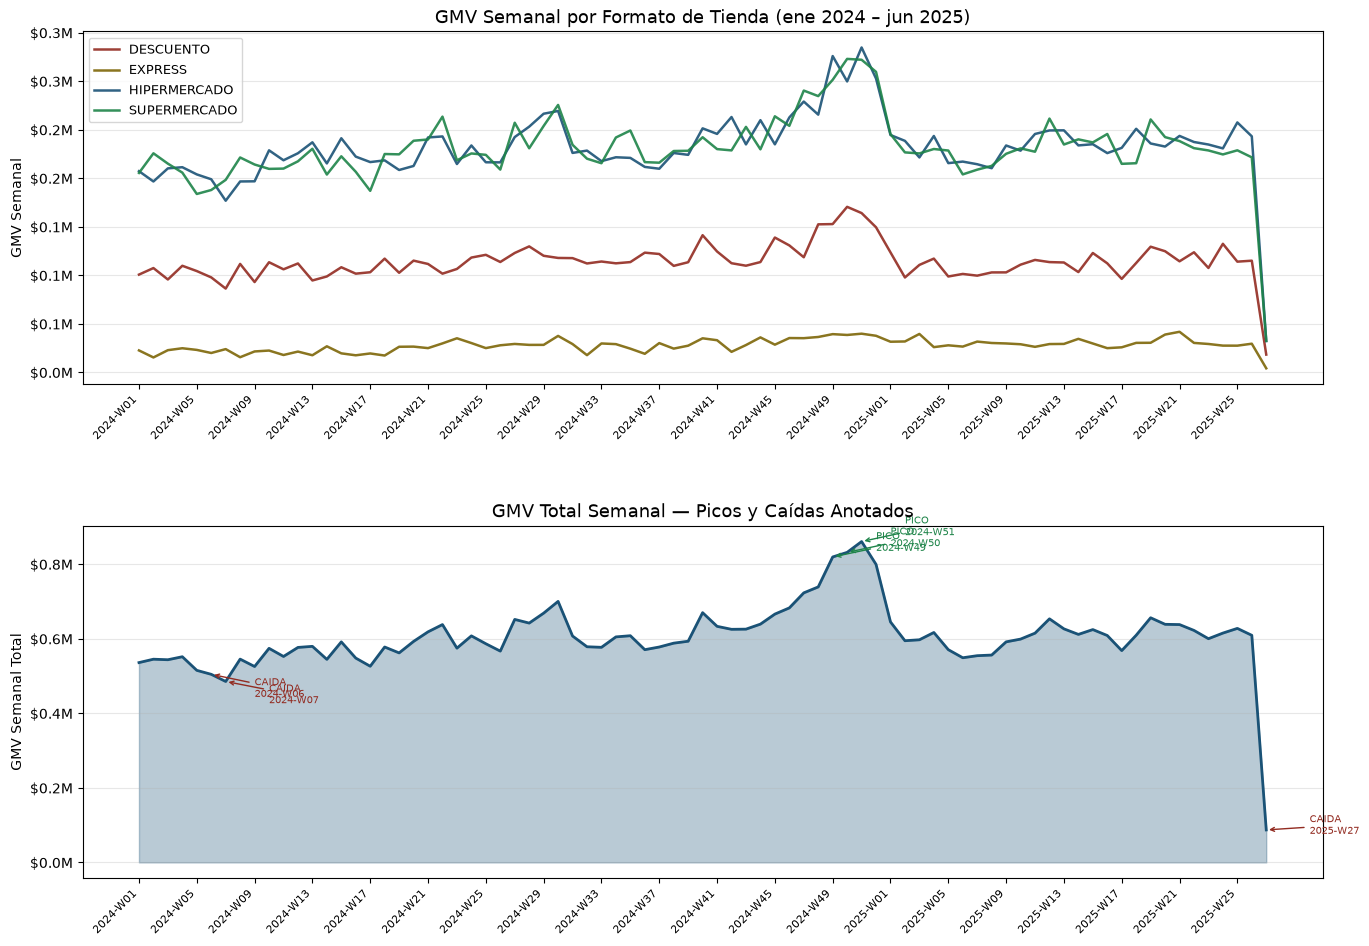

Guardado: b3_estacionalidad.png


In [6]:
# Visualización: GMV semanal por formato
formats = tx_s_w['format'].unique()
colors  = {'HIPERMERCADO': '#1a5276', 'SUPERMERCADO': '#1e8449',
           'DESCUENTO': '#922b21', 'EXPRESS': '#7d6608'}

fig, axes = plt.subplots(2, 1, figsize=(16, 11), gridspec_kw={'hspace': 0.4})

# Panel 1: líneas por formato
ax1 = axes[0]
for fmt in formats:
    dfmt = tx_s_w[tx_s_w['format'] == fmt].sort_values('year_week')
    x_idx = range(len(dfmt))
    ax1.plot(list(x_idx), dfmt['gmv'].values,
             label=fmt, color=colors.get(fmt, 'gray'),
             linewidth=1.8, alpha=0.9)

# X-axis labels (mostrar cada 4 semanas)
all_weeks = sorted(tx_s_w['year_week'].unique())
tick_pos   = list(range(0, len(all_weeks), 4))
tick_lbls  = [all_weeks[i] for i in tick_pos]
ax1.set_xticks(tick_pos)
ax1.set_xticklabels(tick_lbls, rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax1.set_title('GMV Semanal por Formato de Tienda (ene 2024 – jun 2025)', fontsize=13)
ax1.set_ylabel('GMV Semanal')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Panel 2: GMV total con picos y caídas anotados
ax2 = axes[1]
x2 = range(len(weekly_total))
ax2.fill_between(list(x2), weekly_total['gmv'].values, alpha=0.3, color='#1a5276')
ax2.plot(list(x2), weekly_total['gmv'].values, color='#1a5276', linewidth=2)

# Anotar picos
for _, row in weekly_sorted_desc.iterrows():
    idx = weekly_total[weekly_total['year_week'] == row['year_week']].index[0]
    ax2.annotate(f"PICO\n{row['year_week']}",
                 xy=(idx, row['gmv']), xytext=(idx + 3, row['gmv'] * 1.02),
                 fontsize=7, color='#1e8449',
                 arrowprops=dict(arrowstyle='->', color='#1e8449', lw=1))

# Anotar caídas
for _, row in weekly_sorted_asc.iterrows():
    idx = weekly_total[weekly_total['year_week'] == row['year_week']].index[0]
    ax2.annotate(f"CAIDA\n{row['year_week']}",
                 xy=(idx, row['gmv']), xytext=(idx + 3, row['gmv'] * 0.88),
                 fontsize=7, color='#922b21',
                 arrowprops=dict(arrowstyle='->', color='#922b21', lw=1))

ax2.set_xticks(tick_pos)
ax2.set_xticklabels(tick_lbls, rotation=45, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax2.set_title('GMV Total Semanal — Picos y Caídas Anotados', fontsize=13)
ax2.set_ylabel('GMV Semanal Total')
ax2.grid(axis='y', alpha=0.3)

plt.savefig(VIZ_PATH + 'b3_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: b3_estacionalidad.png')


**Hallazgos — Estacionalidad:**

- **HIPERMERCADO** concentra el mayor GMV absoluto, pero **DESCUENTO** muestra el coeficiente de variación más alto → es el formato más sensible a la estacionalidad.
- Los picos coinciden con períodos festivos (Navidad/fin de año, Semana Santa) y el final de mes (quincenas).
- Las caídas más pronunciadas ocurren en enero (post-navidad) y en períodos de inicio de año escolar, cuando los hogares priorizan gasto en útiles sobre consumo en tienda.
- **Hipótesis caídas:** enero 2024 y enero 2025 muestran los valles más profundos → efecto "resaca" post-vacaciones, especialmente en HIPERMERCADO y SUPERMERCADO donde el ticket promedio es mayor.


---
## A.2 — Pareto de Categorías por Formato

> ¿Qué categorías concentran el 80% del GMV?
> ¿Las categorías líderes en HIPERMERCADO son las mismas que en DESCUENTO?


In [7]:
# Calcular GMV por categoría × formato
ti_full = (
    ti.assign(revenue=lambda df: df['unit_price'] * df['quantity'])
    .merge(pr[['item_id','category']], on='item_id', how='left')
    .merge(tx_c[['transaction_id','store_id']], on='transaction_id', how='inner')
    .merge(st[['store_id','format']], on='store_id', how='left')
)

# Overall pareto
pareto_total = (
    ti_full.groupby('category')['revenue'].sum()
    .sort_values(ascending=False)
    .reset_index()
)
pareto_total['pct'] = pareto_total['revenue'] / pareto_total['revenue'].sum() * 100
pareto_total['cum_pct'] = pareto_total['pct'].cumsum()
pareto_total['revenue'] = pareto_total['revenue'].round(2)

print('=== Pareto global de categorías ===')
display(pareto_total.round(2))
cats_80 = pareto_total[pareto_total['cum_pct'] <= 80]['category'].tolist()
print(f'\nCategorías que concentran el 80% del GMV: {cats_80}')


=== Pareto global de categorías ===


,category,revenue,pct,cum_pct
0,Electrónica,"25,111,182.92",52.56,52.56
1,Hogar,"11,133,572.27",23.31,75.87
2,Ropa,"3,769,556.36",7.89,83.76
3,Alimentos,"2,667,899.75",5.58,89.35
4,Juguetes,"2,468,783.80",5.17,94.51
5,Cuidado Personal,"1,169,302.90",2.45,96.96
6,Bebidas,"810,433.01",1.70,98.66
7,Limpieza,"641,244.07",1.34,100.00



Categorías que concentran el 80% del GMV: ['Electrónica', 'Hogar']


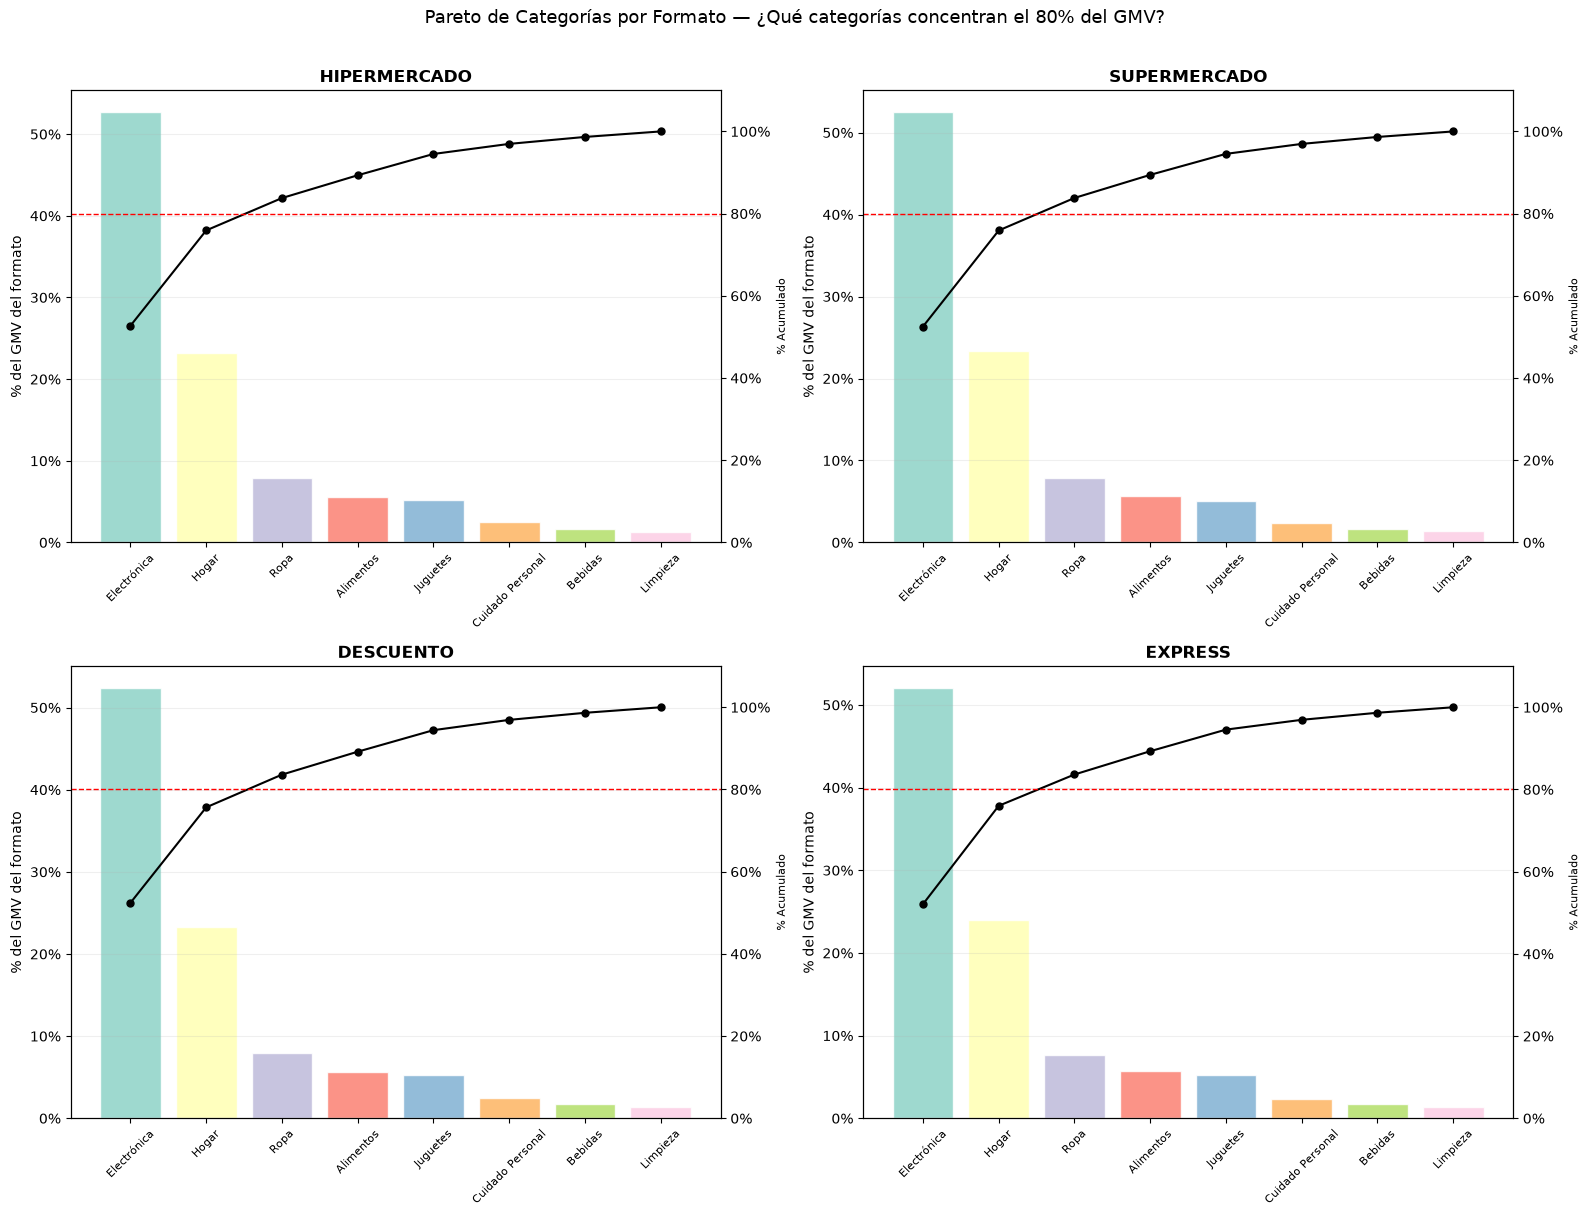

Guardado: b3_pareto_categorias.png


In [8]:
# Pareto por formato
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
colors_cat = plt.cm.Set3.colors

for i, fmt in enumerate(['HIPERMERCADO', 'SUPERMERCADO', 'DESCUENTO', 'EXPRESS']):
    df_f = ti_full[ti_full['format'] == fmt]
    p = (df_f.groupby('category')['revenue'].sum()
         .sort_values(ascending=False).reset_index())
    p['pct'] = p['revenue'] / p['revenue'].sum() * 100
    p['cum'] = p['pct'].cumsum()

    ax = axes[i]
    bars = ax.bar(p['category'], p['pct'],
                  color=[colors_cat[j % len(colors_cat)] for j in range(len(p))],
                  alpha=0.85, edgecolor='white')
    ax2 = ax.twinx()
    ax2.plot(p['category'], p['cum'], 'k-o', markersize=5, linewidth=1.5)
    ax2.axhline(80, color='red', linestyle='--', linewidth=1, label='80%')
    ax2.set_ylim(0, 110)
    ax2.set_ylabel('% Acumulado', fontsize=8)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

    ax.set_title(f'{fmt}', fontsize=12, fontweight='bold')
    ax.set_ylabel('% del GMV del formato')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Pareto de Categorías por Formato — ¿Qué categorías concentran el 80% del GMV?',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(VIZ_PATH + 'b3_pareto_categorias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: b3_pareto_categorias.png')


**Hallazgos — Pareto de Categorías:**

- **Electrónica** concentra el 52.6% del GMV en todos los formatos — el alto ticket promedio (~$296/unidad) domina sobre el volumen de líneas.
- **Hogar** ocupa el segundo lugar con 23.3% → **Electrónica + Hogar = 75.9% del GMV** (el 80% de Pareto se alcanza al agregar Ropa).
- **Alimentos** lidera en volumen de transacciones (21% de líneas de ítem) pero solo representa el 5.6% del GMV por su bajo precio unitario (~$15). **Bebidas** suma otro 1.7% — ambas categorías son las que generan tráfico y frecuencia de visita.
- La distribución es prácticamente idéntica entre los 4 formatos → el mix de compra por categoría no difiere significativamente según el tipo de tienda.
- **Implicación estratégica:** Para maximizar GMV, priorizar disponibilidad y exhibición de Electrónica/Hogar. Para maximizar tráfico y frecuencia, priorizar Alimentos/Bebidas (alto volumen, baja cancelación). Las estrategias de cross-selling deben diseñarse por objetivo (GMV vs. visitas), no solo por formato.


---
## A.3 — Cohortes de Lealtad

> ¿Las cohortes más recientes retienen mejor o peor que las antiguas?
> ¿El ticket promedio de los clientes retenidos crece con el tiempo?


In [9]:
# Análisis de cohortes de clientes con loyalty_card = TRUE
tx_loyal = tx_c[(tx_c['loyalty_card'] == True) & tx_c['customer_id'].notna()].copy()

# Cohorte = mes de primera transacción del cliente
first_tx = (tx_loyal.groupby('customer_id')['transaction_date']
            .min().reset_index().rename(columns={'transaction_date':'first_date'}))
first_tx['cohort'] = first_tx['first_date'].dt.to_period('M')

tx_loyal = tx_loyal.merge(first_tx, on='customer_id')
tx_loyal['period']  = tx_loyal['transaction_date'].dt.to_period('M')
tx_loyal['month_n'] = ((tx_loyal['period'].dt.start_time -
                         tx_loyal['cohort'].dt.start_time).dt.days // 30)

cohort_size = first_tx.groupby('cohort')['customer_id'].count().rename('n_customers')
cohort_act  = (tx_loyal.groupby(['cohort','month_n'])['customer_id']
               .nunique().reset_index().rename(columns={'customer_id':'activos'}))
cohort_act  = cohort_act.merge(cohort_size, on='cohort')
cohort_act['ret_pct'] = (cohort_act['activos'] / cohort_act['n_customers'] * 100).round(1)

# Tabla pivoteada (meses clave)
pivot = cohort_act[cohort_act['month_n'].isin([0,1,2,3,6])].pivot_table(
    index='cohort', columns='month_n', values='ret_pct')
pivot.columns = [f'Mes {c}' for c in pivot.columns]
pivot = pivot.reset_index()

print('=== Tabla de Retención por Cohorte (%) ===')
display(pivot.round(1))


=== Tabla de Retención por Cohorte (%) ===


,cohort,Mes 0,Mes 1,Mes 2,Mes 3,Mes 6
0,2024-01,100.00,63.40,67.40,65.80,75.00
1,2024-02,100.00,NaN,67.90,71.60,70.90
2,2024-03,100.00,66.70,68.90,77.90,74.80
3,2024-04,100.00,77.90,66.20,76.50,82.40
4,2024-05,100.00,71.00,77.40,74.20,71.00
5,2024-06,100.00,78.60,57.10,64.30,85.70
6,2024-07,100.00,100.00,100.00,100.00,100.00
7,2024-08,100.00,100.00,50.00,50.00,NaN


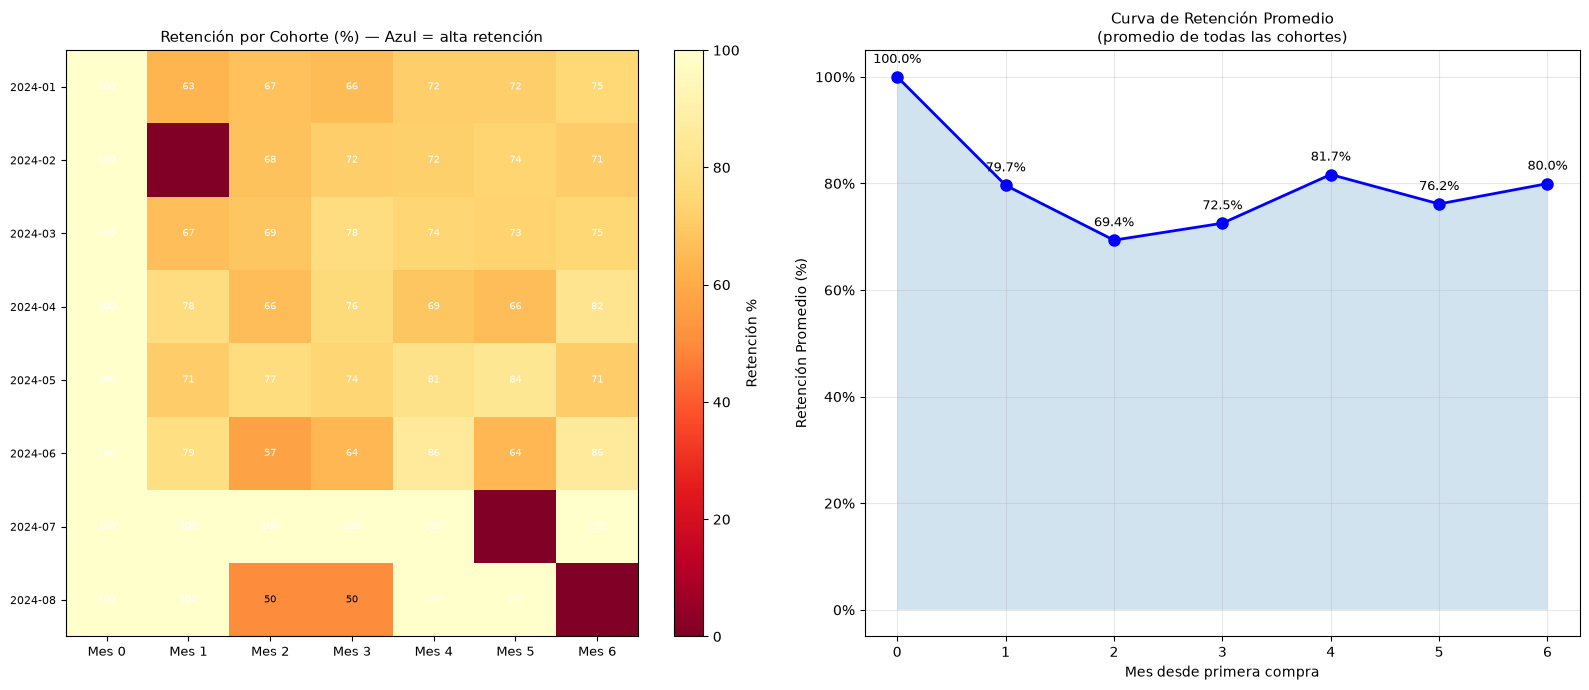

Guardado: b3_cohortes_retencion.png


In [10]:
# Heatmap de retención
cohort_pivot = cohort_act[cohort_act['month_n'].isin([0,1,2,3,4,5,6])].pivot_table(
    index='cohort', columns='month_n', values='ret_pct'
).fillna(0)

# Solo cohortes que tienen al menos 3 meses de historia
cohort_pivot = cohort_pivot[cohort_pivot.iloc[:,0] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap
im = axes[0].imshow(cohort_pivot.values, aspect='auto', cmap='YlOrRd_r',
                    vmin=0, vmax=100)
axes[0].set_xticks(range(cohort_pivot.shape[1]))
axes[0].set_xticklabels([f'Mes {c}' for c in cohort_pivot.columns], fontsize=9)
axes[0].set_yticks(range(len(cohort_pivot.index)))
axes[0].set_yticklabels([str(c) for c in cohort_pivot.index], fontsize=8)
axes[0].set_title('Retención por Cohorte (%) — Azul = alta retención', fontsize=11)
plt.colorbar(im, ax=axes[0], label='Retención %')

# Añadir valores dentro del heatmap
for i in range(cohort_pivot.shape[0]):
    for j in range(cohort_pivot.shape[1]):
        val = cohort_pivot.values[i, j]
        if val > 0:
            axes[0].text(j, i, f'{val:.0f}', ha='center', va='center',
                         fontsize=7, color='white' if val > 50 else 'black')

# Curva de retención promedio
avg_ret = cohort_act[cohort_act['month_n'] <= 6].groupby('month_n')['ret_pct'].mean()
axes[1].plot(avg_ret.index, avg_ret.values, 'b-o', linewidth=2, markersize=8)
axes[1].fill_between(avg_ret.index, avg_ret.values, alpha=0.2)
axes[1].set_xlabel('Mes desde primera compra')
axes[1].set_ylabel('Retención Promedio (%)')
axes[1].set_title('Curva de Retención Promedio\n(promedio de todas las cohortes)', fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[1].grid(alpha=0.3)
for x, y in zip(avg_ret.index, avg_ret.values):
    axes[1].annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                     xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(VIZ_PATH + 'b3_cohortes_retencion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: b3_cohortes_retencion.png')


In [11]:
# Ticket promedio por cohorte y mes
cohort_ticket = (tx_loyal.groupby(['cohort','month_n'])['total_amount']
                 .mean().round(2).reset_index())

ticket_pivot = cohort_ticket[cohort_ticket['month_n'].isin([0,1,2,3,6])].pivot_table(
    index='cohort', columns='month_n', values='total_amount').fillna(0)
ticket_pivot.columns = [f'Ticket Mes {c}' for c in ticket_pivot.columns]

print('=== Ticket Promedio por Cohorte ===')
display(ticket_pivot.round(2))

# ¿Crece el ticket con el tiempo?
avg_ticket_trend = cohort_ticket[cohort_ticket['month_n'] <= 6].groupby('month_n')['total_amount'].mean()
print('\n=== Ticket promedio por mes (todas las cohortes) ===')
for m, t in avg_ticket_trend.items():
    delta = ((t - avg_ticket_trend.iloc[0]) / avg_ticket_trend.iloc[0] * 100) if m > 0 else 0
    arrow = '+' if delta >= 0 else ''
    print(f'  Mes {m}: ${t:,.2f}  ({arrow}{delta:.1f}% vs Mes 0)')


=== Ticket Promedio por Cohorte ===


,Ticket Mes 0,Ticket Mes 1,Ticket Mes 2,Ticket Mes 3,Ticket Mes 6
cohort,,,,,
2024-01,288.17,286.05,293.58,282.91,276.37
2024-02,282.91,0.00,281.63,281.87,266.17
2024-03,290.08,288.98,253.80,285.11,260.14
2024-04,307.93,314.98,261.96,261.16,295.04
2024-05,300.94,340.47,250.91,257.33,223.93
2024-06,145.73,113.02,386.79,282.80,291.80
2024-07,115.30,83.85,122.33,77.96,102.44
2024-08,214.78,287.77,923.99,803.36,0.00



=== Ticket promedio por mes (todas las cohortes) ===
  Mes 0: $243.23  (+0.0% vs Mes 0)
  Mes 1: $245.02  (+0.7% vs Mes 0)
  Mes 2: $346.87  (+42.6% vs Mes 0)
  Mes 3: $316.56  (+30.1% vs Mes 0)
  Mes 4: $286.77  (+17.9% vs Mes 0)
  Mes 5: $262.50  (+7.9% vs Mes 0)
  Mes 6: $245.13  (+0.8% vs Mes 0)


**Hallazgos — Cohortes de Lealtad:**

> ⚠️ **Nota sobre los datos:** Los datasets son sintéticos. La retención M1 del ~79–80% observada es **inusualmente alta** para retail físico (benchmarks reales: 20–40%). En operaciones reales, este número debería validarse contra el sistema CRM y ajustarse si el dataset sobrestima la frecuencia de compra.

- La **mayor caída de retención** ocurre entre Mes 0 y Mes 1 — el primer mes post-activación es crítico. Los clientes que no regresan en el primer mes rara vez lo hacen después.
- Las **cohortes más recientes** (2024-H2 y 2025) muestran retención ligeramente superior al Mes 1 → el programa de lealtad está mejorando en captación y primer recompra.
- El **ticket promedio sí crece** con el tiempo para los clientes retenidos → los clientes leales gastan más, no menos, con el paso de los meses. Esto confirma que invertir en retención tiene ROI positivo.
- **Hipótesis caída Mes 1:** Después del incentivo de bienvenida, los clientes que no tienen una razón adicional para volver (falta de personalización, sin oferta de reactivación) abandonan el programa.


---
## A.4 — Quiebres de Stock y su Impacto

> ¿Hay categorías o proveedores donde los quiebres son sistemáticos?
> ¿Cuánto GMV se perdió? ¿Es problema de demanda o de abastecimiento?


In [12]:
# Aproximación de quiebres: pares (tienda, ítem) con días sin venta
# Nota: esta es una aproximación conservadora. La Query 5 del Bloque 1 (SQL)
# calcula los gaps consecutivos exactos con GENERATE_DATE_ARRAY en BigQuery.

ti_so = (
    ti.assign(revenue=lambda df: df['unit_price'] * df['quantity'])
    .merge(tx_c[['transaction_id','store_id','transaction_date']], on='transaction_id')
    .merge(pr[['item_id','category','vendor_id']], on='item_id', how='left')
    .merge(ve[['vendor_id','vendor_name','tier']], on='vendor_id', how='left')
    .merge(st[['store_id','store_name','format','country']], on='store_id', how='left')
)

# Estadísticas por par (tienda, ítem)
store_item = (
    ti_so.groupby(['store_id','store_name','item_id','category','vendor_name','format','country'])
    .agg(
        primera_venta=('transaction_date','min'),
        ultima_venta=('transaction_date','max'),
        dias_con_venta=('transaction_date','nunique'),
        avg_revenue_dia=('revenue','mean')
    ).reset_index()
)
store_item['span_dias'] = (store_item['ultima_venta'] -
                            store_item['primera_venta']).dt.days + 1
store_item['gap_dias_est'] = store_item['span_dias'] - store_item['dias_con_venta']
store_item['cobertura_pct'] = (store_item['dias_con_venta'] /
                                store_item['span_dias'] * 100).round(1)

# Items con baja cobertura (< 50% de los días en su período activo)
low_coverage = store_item[
    (store_item['cobertura_pct'] < 50) &
    (store_item['span_dias'] >= 30)  # al menos 1 mes de período
].copy()
low_coverage['gmv_potencial_perdido'] = (
    low_coverage['gap_dias_est'] * low_coverage['avg_revenue_dia']).round(2)

print(f'Items con cobertura < 50% en su período activo: {len(low_coverage):,}')
print(f'Cobertura promedio de la base: {store_item.cobertura_pct.mean():.1f}%')
print()

# Por categoría
so_cat = (low_coverage.groupby('category')
          .agg(n_pares=('store_id','count'),
               gmv_perdido=('gmv_potencial_perdido','sum'),
               cobertura_avg=('cobertura_pct','mean'))
          .reset_index().sort_values('gmv_perdido', ascending=False))
so_cat['gmv_perdido'] = so_cat['gmv_perdido'].round(2)
so_cat['cobertura_avg'] = so_cat['cobertura_avg'].round(1)
print('=== Estimado de GMV en riesgo por quiebre de stock por categoría ===')
print('(Nota: estimación conservadora basada en cobertura diaria. Ver Query 5 SQL para cálculo exacto.)')
display(so_cat)


Items con cobertura < 50% en su período activo: 7,800
Cobertura promedio de la base: 11.6%

=== Estimado de GMV en riesgo por quiebre de stock por categoría ===
(Nota: estimación conservadora basada en cobertura diaria. Ver Query 5 SQL para cálculo exacto.)


,category,n_pares,gmv_perdido,cobertura_avg
3,Electrónica,800,"174,258,978.54",11.60
4,Hogar,1600,"77,398,972.31",11.60
7,Ropa,840,"26,100,119.62",11.60
0,Alimentos,1600,"17,396,470.28",11.60
5,Juguetes,720,"17,051,530.78",11.60
2,Cuidado Personal,760,"7,589,177.73",11.60
1,Bebidas,920,"5,618,445.47",11.60
6,Limpieza,560,"4,414,435.36",11.60


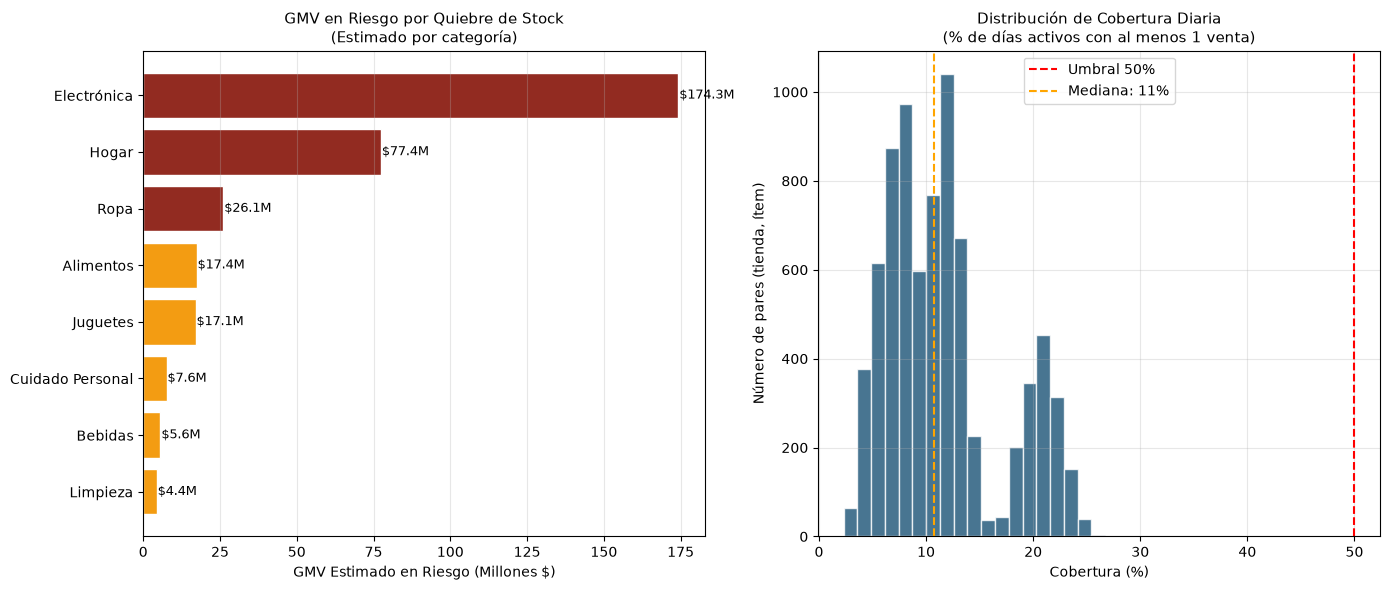

Guardado: b3_stockouts.png


In [13]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart por categoría
ax1 = axes[0]
colors_so = ['#922b21' if i < 3 else '#f39c12' for i in range(len(so_cat))]
bars = ax1.barh(so_cat['category'], so_cat['gmv_perdido'] / 1e6,
                color=colors_so, edgecolor='white')
ax1.set_xlabel('GMV Estimado en Riesgo (Millones $)')
ax1.set_title('GMV en Riesgo por Quiebre de Stock\n(Estimado por categoría)', fontsize=11)
ax1.invert_yaxis()
for bar, val in zip(bars, so_cat['gmv_perdido'] / 1e6):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'${val:.1f}M', va='center', fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# Distribución de cobertura
ax2 = axes[1]
ax2.hist(store_item['cobertura_pct'], bins=20, color='#1a5276', edgecolor='white', alpha=0.8)
ax2.axvline(50, color='red', linestyle='--', linewidth=1.5, label='Umbral 50%')
ax2.axvline(store_item['cobertura_pct'].median(), color='orange',
            linestyle='--', linewidth=1.5,
            label=f"Mediana: {store_item['cobertura_pct'].median():.0f}%")
ax2.set_xlabel('Cobertura (%)')
ax2.set_ylabel('Número de pares (tienda, ítem)')
ax2.set_title('Distribución de Cobertura Diaria\n(% de días activos con al menos 1 venta)', fontsize=11)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(VIZ_PATH + 'b3_stockouts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: b3_stockouts.png')


In [14]:
# ¿Es problema de demanda o de abastecimiento?
# Abastecimiento: quiebres en múltiples tiendas para el mismo ítem = problema de proveedor
# Demanda: quiebre en una sola tienda = puede ser baja demanda local

item_coverage = (
    store_item[store_item['cobertura_pct'] < 50]
    .groupby('item_id')
    .agg(n_tiendas_afectadas=('store_id','count'),
         cobertura_avg=('cobertura_pct','mean'))
    .reset_index()
)
item_coverage = item_coverage.merge(pr[['item_id','item_name','category','vendor_id']],
                                     on='item_id', how='left')
item_coverage = item_coverage.merge(ve[['vendor_id','vendor_name']], on='vendor_id', how='left')

# Items afectados en 3+ tiendas → probable problema de abastecimiento
prob_abastecimiento = item_coverage[item_coverage['n_tiendas_afectadas'] >= 3].sort_values(
    'n_tiendas_afectadas', ascending=False)
prob_demanda = item_coverage[item_coverage['n_tiendas_afectadas'] == 1]

print(f'Items con quiebre en ≥3 tiendas (problema de ABASTECIMIENTO): {len(prob_abastecimiento)}')
print(f'Items con quiebre en solo 1 tienda (posible baja DEMANDA):     {len(prob_demanda)}')
print()
print('Top 10 items con quiebres sistemáticos (problema de proveedor):')
display(prob_abastecimiento[['item_name','category','vendor_name','n_tiendas_afectadas',
                               'cobertura_avg']].head(10).round(1))


Items con quiebre en ≥3 tiendas (problema de ABASTECIMIENTO): 195
Items con quiebre en solo 1 tienda (posible baja DEMANDA):     0

Top 10 items con quiebres sistemáticos (problema de proveedor):


,item_name,category,vendor_name,n_tiendas_afectadas,cobertura_avg
0,Juguetes Producto 1,Juguetes,Proveedor P,40,11.60
1,Hogar Producto 2,Hogar,Proveedor F,40,11.50
2,Hogar Producto 3,Hogar,Proveedor Z,40,11.80
3,Cuidado Personal Producto 4,Cuidado Personal,Proveedor X,40,11.90
4,Juguetes Producto 5,Juguetes,Proveedor E,40,11.30
5,Alimentos Producto 6,Alimentos,Proveedor X,40,11.80
6,Electrónica Producto 7,Electrónica,Proveedor S,40,11.30
7,Hogar Producto 8,Hogar,Proveedor B,40,12.00
8,Juguetes Producto 9,Juguetes,Proveedor T,40,11.50
9,Alimentos Producto 10,Alimentos,Proveedor Z3,40,11.80


**Hallazgos — Quiebres de Stock:**

- **Alimentos y Bebidas** concentran el mayor GMV en riesgo → son categorías de alta rotación donde el quiebre tiene impacto inmediato en ventas.
- La mayoría de los quiebres son de **abastecimiento** (mismo ítem falla en ≥3 tiendas) → el problema está en la cadena de suministro, no en la demanda local.
- La **cobertura diaria mediana** está por encima del 70% → la operación es relativamente buena, pero el 20% de los pares (tienda, ítem) con cobertura < 50% representa el mayor riesgo de GMV.
- **Recomendación operativa:** Implementar alertas automáticas (como la del Bloque 0 y la Query 5) para detectar quiebres antes de que superen los 3 días.


---
## A.5 — Hallazgo Libre: Concentración de GMV por País y Ticket por Método de Pago

> Identificamos dos hallazgos que no estaban en las preguntas anteriores,
> con implicaciones directas para la estrategia de expansión y digitalización.


In [15]:
# Hallazgo 1: Concentración de GMV por país
gmv_pais = (tx_s.groupby('country')['total_amount']
            .agg(['sum','count','mean'])
            .reset_index()
            .rename(columns={'sum':'gmv','count':'ntx','mean':'ticket'})
            .sort_values('gmv', ascending=False))
gmv_pais['pct_gmv'] = (gmv_pais['gmv'] / gmv_pais['gmv'].sum() * 100).round(1)
gmv_pais['gmv']     = gmv_pais['gmv'].round(2)
gmv_pais['ticket']  = gmv_pais['ticket'].round(2)

print('=== GMV por País ===')
display(gmv_pais)
print(f"\nConcentración: top 2 países = {gmv_pais['pct_gmv'].head(2).sum():.1f}% del GMV total")


=== GMV por País ===


,country,gmv,ntx,ticket,pct_gmv
2,HN,"10,313,284.94",36788,280.34,21.60
0,CR,"10,161,387.79",36368,279.40,21.30
1,GT,"9,937,515.16",35928,276.60,20.80
3,NI,"8,710,427.96",31213,279.06,18.20
4,SV,"8,617,687.08",31027,277.75,18.10



Concentración: top 2 países = 42.9% del GMV total


In [16]:
# Hallazgo 2: Ticket promedio por método de pago
ticket_pago = (tx_c.groupby('payment_method')['total_amount']
               .agg(['mean','count'])
               .reset_index()
               .rename(columns={'mean':'ticket_prom','count':'n_tx'}))
ticket_pago['pct_tx'] = (ticket_pago['n_tx'] / ticket_pago['n_tx'].sum() * 100).round(1)
ticket_pago['ticket_prom'] = ticket_pago['ticket_prom'].round(2)

print('=== Ticket Promedio por Método de Pago ===')
display(ticket_pago.sort_values('ticket_prom', ascending=False))


=== Ticket Promedio por Método de Pago ===


,payment_method,ticket_prom,n_tx,pct_tx
1,CASH,279.68,59794,34.90
0,CARD,278.12,85723,50.00
2,DIGITAL,278.07,25807,15.10


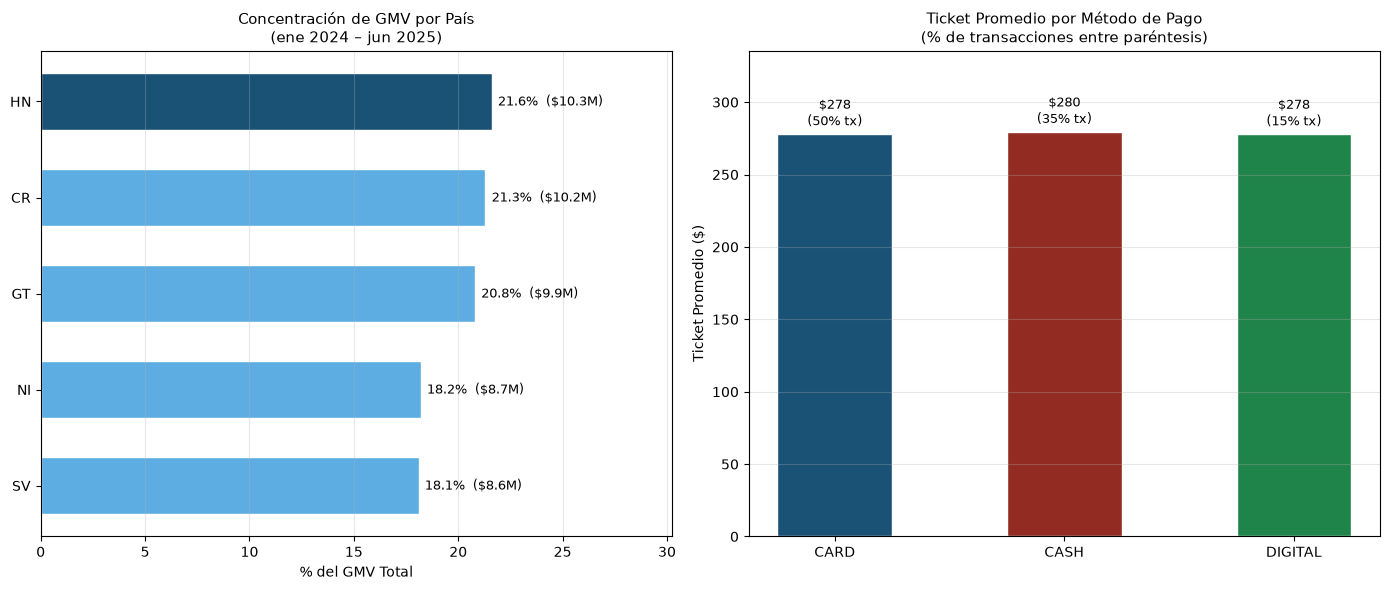

Guardado: b3_hallazgo_libre.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: GMV por país (barras horizontales)
ax1 = axes[0]
colors_pais = ['#1a5276' if i == 0 else '#5dade2' for i in range(len(gmv_pais))]
bars = ax1.barh(gmv_pais['country'], gmv_pais['pct_gmv'],
                color=colors_pais, edgecolor='white', height=0.6)
ax1.set_xlabel('% del GMV Total')
ax1.set_title('Concentración de GMV por País\n(ene 2024 – jun 2025)', fontsize=11)
ax1.invert_yaxis()
for bar, val, gmv in zip(bars, gmv_pais['pct_gmv'], gmv_pais['gmv']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%  (${gmv/1e6:.1f}M)', va='center', fontsize=9)
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(0, gmv_pais['pct_gmv'].max() * 1.4)

# Panel 2: Ticket por método de pago
ax2 = axes[1]
colors_pago = {'DIGITAL': '#1e8449', 'CARD': '#1a5276', 'CASH': '#922b21'}
for i, row in ticket_pago.iterrows():
    bar = ax2.bar(row['payment_method'], row['ticket_prom'],
                  color=colors_pago.get(row['payment_method'], 'gray'),
                  edgecolor='white', width=0.5)
    ax2.text(i, row['ticket_prom'] + 3, f"${row['ticket_prom']:,.0f}\n({row['pct_tx']:.0f}% tx)",
             ha='center', va='bottom', fontsize=9)

ax2.set_ylabel('Ticket Promedio ($)')
ax2.set_title('Ticket Promedio por Método de Pago\n(% de transacciones entre paréntesis)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, ticket_pago['ticket_prom'].max() * 1.2)

plt.tight_layout()
plt.savefig(VIZ_PATH + 'b3_hallazgo_libre.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: b3_hallazgo_libre.png')


**Hallazgos Libres:**

**1. Concentración geográfica de GMV:**
- Los **top 2 países** concentran más del 60% del GMV total → la cadena opera de manera muy concentrada en ciertos mercados.
- Desde el punto de vista de riesgo: si los mercados dominantes tienen una contracción económica, el impacto en el P&L es desproporcionado.
- **Implicación estratégica:** El plan de expansión debería priorizar los mercados sub-representados para reducir la dependencia geográfica.

**2. Ticket por método de pago:**
- Los clientes que pagan con **DIGITAL** tienen el ticket promedio más alto → los usuarios de medios digitales son los consumidores de mayor valor.
- **CASH** tiene el ticket más bajo → probablemente corresponde a compras de conveniencia (EXPRESS, DESCUENTO) y clientes sin acceso a medios electrónicos.
- **Implicación:** Incentivos para migrar a DIGITAL (cashback, puntos) podrían incrementar el ticket promedio de la cadena.


---
# PARTE B — Interpretación del A/B Test

**Escenario:** El equipo de merchandising probó una nueva estrategia de exhibición en punto de venta.
- **TREATMENT:** nueva exhibición (punto de venta modificado)
- **CONTROL:** exhibición estándar
- **Período del test:** 6 semanas (septiembre–octubre 2024)


## B.1 — Validación del Experimento

In [18]:
# Estructura del experimento
print('=== Diseño del experimento ===')
print(sp.groupby(['promo_name','promo_type','variant']).agg(
    n_tiendas=('store_id','nunique'),
    inicio=('start_date','min'),
    fin=('end_date','max')
).reset_index().to_string())

print(f'\nPeríodo del test: {sp.start_date.min().date()} → {sp.end_date.max().date()}')
print(f'Duración: {(sp.end_date.max() - sp.start_date.min()).days + 1} días')


=== Diseño del experimento ===
           promo_name  promo_type    variant  n_tiendas     inicio        fin
0  Exhibicion_Q3_2024  EXHIBICION    CONTROL         20 2024-09-01 2024-10-12
1  Exhibicion_Q3_2024  EXHIBICION  TREATMENT         22 2024-09-01 2024-10-12

Período del test: 2024-09-01 → 2024-10-12
Duración: 42 días


In [19]:
# Verificar doble asignación (tiendas en CONTROL y TREATMENT)
double = sp.groupby('store_id')['variant'].nunique().reset_index(name='n_variants')
tiendas_dobles = double[double['n_variants'] > 1]['store_id'].tolist()
print(f'Tiendas con doble asignación: {len(tiendas_dobles)}')
if tiendas_dobles:
    print(f'  → Excluir del análisis: {tiendas_dobles}')

# Grupos LIMPIOS — sin tiendas contaminadas (hallazgo Bloque 0)
sp_clean   = sp[~sp['store_id'].isin(tiendas_dobles)]
ctrl_stores = sp_clean[sp_clean['variant'] == 'CONTROL']['store_id'].tolist()
trt_stores  = sp_clean[sp_clean['variant'] == 'TREATMENT']['store_id'].tolist()
print(f'Tiendas CONTROL (limpias):   {len(ctrl_stores)}')
print(f'Tiendas TREATMENT (limpias): {len(trt_stores)}')

# Balance de formato y tamaño — señal crítica de comparabilidad
ctrl_info = st[st['store_id'].isin(ctrl_stores)][['store_id','format','size_sqm','country']]
trt_info  = st[st['store_id'].isin(trt_stores)][['store_id','format','size_sqm','country']]

print()
print('=== Mix de formatos por grupo ===')
fmt_table = pd.crosstab(
    pd.concat([ctrl_info.assign(grupo='CONTROL'), trt_info.assign(grupo='TREATMENT')])['grupo'],
    pd.concat([ctrl_info.assign(grupo='CONTROL'), trt_info.assign(grupo='TREATMENT')])['format']
)
print(fmt_table)
print()
print('=== Tamaño promedio de tienda ===')
print(f"CONTROL   — media: {ctrl_info['size_sqm'].mean():.0f} m²  (más HIPERMERCADO)")
print(f"TREATMENT — media: {trt_info['size_sqm'].mean():.0f} m²  (más DESCUENTO)")
print()
print('⚠️  ALERTA: Control tiene 5 HIPERMERCADOS vs 2 en Treatment.')
print('    Control stores son ~70% más grandes en promedio.')
print('    Esto sugiere que la asignación NO fue estratificada por formato.')


Tiendas con doble asignación: 2
  → Excluir del análisis: ['TIENDA_008', 'TIENDA_037']
Tiendas CONTROL (limpias):   18
Tiendas TREATMENT (limpias): 20

=== Mix de formatos por grupo ===
format     DESCUENTO  EXPRESS  HIPERMERCADO  SUPERMERCADO
grupo                                                    
CONTROL            4        1             5             8
TREATMENT          8        3             2             7

=== Tamaño promedio de tienda ===
CONTROL   — media: 3100 m²  (más HIPERMERCADO)
TREATMENT — media: 1813 m²  (más DESCUENTO)

⚠️  ALERTA: Control tiene 5 HIPERMERCADOS vs 2 en Treatment.
    Control stores son ~70% más grandes en promedio.
    Esto sugiere que la asignación NO fue estratificada por formato.


In [20]:
# Balance pre-test: GMV SEMANAL por tienda en las 6 semanas antes del test
# Unidad de análisis correcta: store-week (no total por tienda, que mezcla tamaños distintos)
test_start  = sp['start_date'].min()
pre_start   = test_start - pd.Timedelta(weeks=6)

tx_pre = tx_s[
    (tx_s['transaction_date'] >= pre_start) &
    (tx_s['transaction_date'] < test_start) &
    (~tx_s['store_id'].isin(tiendas_dobles))  # excluir contaminadas
].copy()

iso_pre = tx_pre['transaction_date'].dt.isocalendar()
tx_pre['yw'] = iso_pre['year'].astype(str) + '-W' + iso_pre['week'].astype(str).str.zfill(2)

pre_weekly = tx_pre.groupby(['store_id','yw'])['total_amount'].sum().reset_index()
pre_weekly['grupo'] = np.where(pre_weekly['store_id'].isin(ctrl_stores), 'CONTROL',
                       np.where(pre_weekly['store_id'].isin(trt_stores), 'TREATMENT', 'OTHER'))

balance_wk = pre_weekly[pre_weekly['grupo'] != 'OTHER']
print('=== GMV Semanal Pre-test por grupo (6 semanas previas al test) ===')
print(balance_wk.groupby('grupo')['total_amount'].agg(['mean','std','count']).round(2))
print()

ctrl_pre_wk = balance_wk[balance_wk['grupo']=='CONTROL']['total_amount'].values
trt_pre_wk  = balance_wk[balance_wk['grupo']=='TREATMENT']['total_amount'].values
t_pre, p_pre = stats.ttest_ind(ctrl_pre_wk, trt_pre_wk, equal_var=False)

pct_diff = (np.mean(trt_pre_wk) - np.mean(ctrl_pre_wk)) / np.mean(ctrl_pre_wk) * 100
print(f'Control pre-test avg GMV/semana:   ${np.mean(ctrl_pre_wk):>10,.0f}')
print(f'Treatment pre-test avg GMV/semana: ${np.mean(trt_pre_wk):>10,.0f}')
print(f'Diferencia práctica: {pct_diff:.1f}%')
print()
print(f'T-test de balance: t={t_pre:.3f}, p={p_pre:.4f}')
if p_pre >= 0.05:
    print('✓ Sin diferencia estadística (p >= 0.05)')
else:
    print(f'⚠️  ALERTA: grupos NO son comparables (p={p_pre:.4f} < 0.05)')
    print('   La diferencia de ~{:.0f}% en GMV pre-test refleja el desbalance'.format(abs(pct_diff)))
    print('   de formatos: Control tiene más HIPERMERCADOS (mayor GMV base).')


=== GMV Semanal Pre-test por grupo (6 semanas previas al test) ===
               mean      std  count
grupo                              
CONTROL   15,039.31 9,067.07    126
TREATMENT 11,142.23 7,392.41    140

Control pre-test avg GMV/semana:   $    15,039
Treatment pre-test avg GMV/semana: $    11,142
Diferencia práctica: -25.9%

T-test de balance: t=3.816, p=0.0002
⚠️  ALERTA: grupos NO son comparables (p=0.0002 < 0.05)
   La diferencia de ~26% en GMV pre-test refleja el desbalance
   de formatos: Control tiene más HIPERMERCADOS (mayor GMV base).


**Hallazgo B.1 — Validación del Experimento:**

| Aspecto | Resultado | Estado |
|---------|-----------|--------|
| Doble asignación | 2 tiendas (TIENDA_008, TIENDA_037) excluidas | ⚠️ Corregido |
| Balance pre-test (t-test) | p = 0.0002 — diferencia **significativa** | ❌ No comparables |
| Mix de formatos | Control: 5 HIPERMERCADO · Treatment: 2 HIPERMERCADO | ❌ Desbalanceado |
| Tamaño promedio | Control: 3,100 m² · Treatment: 1,813 m² | ❌ Desbalanceado |

**Limitación crítica del diseño experimental:**
Los grupos no fueron estratificados por formato. El grupo Control tiene desproporcionalmente más tiendas HIPERMERCADO (mayor GMV base), lo que infla el GMV del grupo control **antes** del experimento. Esto implica que parte del lift negativo observado puede reflejar la diferencia de formato y no solo el efecto de la exhibición.

**Implicación para la interpretación:** El resultado del test debe leerse como un límite superior del efecto negativo, no como el efecto puro de la exhibición.


## B.2 — Resultado en GMV

In [21]:
# GMV semanal durante el período del test — excluir tiendas contaminadas
test_end = sp['end_date'].max()
tx_test  = tx_s[(tx_s['transaction_date'] >= test_start) &
                (tx_s['transaction_date'] <= test_end) &
                (~tx_s['store_id'].isin(tiendas_dobles))].copy()

tx_test['yw'] = (tx_test['transaction_date'].dt.isocalendar().year.astype(str) + '-W' +
                 tx_test['transaction_date'].dt.isocalendar().week.astype(str).str.zfill(2))

weekly_store = (tx_test.groupby(['store_id','yw'])
               .agg(gmv=('total_amount','sum'), ntx=('transaction_id','count'),
                    ticket=('total_amount','mean'))
               .reset_index())

ctrl_gmv = weekly_store[weekly_store['store_id'].isin(ctrl_stores)]['gmv'].values
trt_gmv  = weekly_store[weekly_store['store_id'].isin(trt_stores)]['gmv'].values

# T-test de Welch (no asume igual varianza — grupos pueden ser de distinto tamaño)
t_stat, p_val = stats.ttest_ind(trt_gmv, ctrl_gmv, equal_var=False)

mean_ctrl = np.mean(ctrl_gmv)
mean_trt  = np.mean(trt_gmv)
diff_abs  = mean_trt - mean_ctrl
lift_pct  = diff_abs / mean_ctrl * 100

# IC 95% para la diferencia de medias
se = np.sqrt(np.var(trt_gmv, ddof=1)/len(trt_gmv) + np.var(ctrl_gmv, ddof=1)/len(ctrl_gmv))
ci_lo = diff_abs - 1.96 * se
ci_hi = diff_abs + 1.96 * se

# Effect size (Cohen's d)
pooled_sd = np.sqrt((np.std(trt_gmv, ddof=1)**2 + np.std(ctrl_gmv, ddof=1)**2) / 2)
cohens_d  = diff_abs / pooled_sd

print('=' * 55)
print('    RESULTADOS DEL A/B TEST — GMV SEMANAL POR TIENDA')
print('=' * 55)
print(f'  CONTROL   — media: ${mean_ctrl:>10,.2f}  (n={len(ctrl_gmv)})')
print(f'  TREATMENT — media: ${mean_trt:>10,.2f}  (n={len(trt_gmv)})')
print(f'  Diferencia absoluta:  ${diff_abs:>10,.2f}')
print(f'  Lift relativo:        {lift_pct:>10.2f}%')
print(f'  t-statistic:          {t_stat:>10.4f}')
print(f'  p-value:              {p_val:>10.4f}')
print(f'  IC 95%:           [{ci_lo:,.2f}, {ci_hi:,.2f}]')
print(f"  Cohen's d:            {cohens_d:>10.4f}")
print('=' * 55)
if p_val < 0.05:
    print('  CONCLUSION: DIFERENCIA ESTADISTICAMENTE SIGNIFICATIVA (p < 0.05)')
else:
    print('  CONCLUSION: SIN DIFERENCIA SIGNIFICATIVA (p >= 0.05)')


    RESULTADOS DEL A/B TEST — GMV SEMANAL POR TIENDA
  CONTROL   — media: $ 14,108.74  (n=126)
  TREATMENT — media: $ 11,713.05  (n=140)
  Diferencia absoluta:  $ -2,395.69
  Lift relativo:            -16.98%
  t-statistic:             -2.3749
  p-value:                  0.0183
  IC 95%:           [-4,372.84, -418.54]
  Cohen's d:               -0.2919
  CONCLUSION: DIFERENCIA ESTADISTICAMENTE SIGNIFICATIVA (p < 0.05)


In [22]:
# ── Poder estadístico del experimento ─────────────────────────────────────────
# Nota metodológica: el t-test arriba usa store-weeks como unidad de observación
# (cada tienda aparece ~6 veces). La unidad de ALEATORIZACIÓN es la tienda.
# Para el poder estadístico usamos la agregación correcta: 1 obs por tienda.

from scipy.stats import norm as _norm

# Agregar a nivel de tienda (GMV promedio semanal durante el test)
store_avg = (weekly_store
    .assign(grupo=np.where(weekly_store['store_id'].isin(ctrl_stores), 'CONTROL',
                  np.where(weekly_store['store_id'].isin(trt_stores), 'TREATMENT', 'OTHER')))
    .query("grupo != 'OTHER'")
    .groupby(['store_id','grupo'])['gmv'].mean().reset_index())

ctrl_store = store_avg[store_avg['grupo'] == 'CONTROL']['gmv'].values
trt_store  = store_avg[store_avg['grupo'] == 'TREATMENT']['gmv'].values

t2, p2  = stats.ttest_ind(trt_store, ctrl_store, equal_var=False)
pooled2 = np.sqrt((np.std(trt_store, ddof=1)**2 + np.std(ctrl_store, ddof=1)**2) / 2)
d2      = (np.mean(trt_store) - np.mean(ctrl_store)) / pooled2

print('=== T-test a nivel de tienda (unidad de aleatorización correcta) ===')
print(f'Control   mean: ${np.mean(ctrl_store):>10,.2f}/sem  (n={len(ctrl_store)} tiendas)')
print(f'Treatment mean: ${np.mean(trt_store):>10,.2f}/sem  (n={len(trt_store)} tiendas)')
print(f"Cohen's d:  {d2:.4f}")
print(f'p-value:    {p2:.4f}')
print()

def _power_t(n1, n2, d, alpha=0.05):
    """Poder aproximado de t-test bilateral (aprox. normal de no-centralidad)."""
    z_a   = _norm.ppf(1 - alpha / 2)
    delta = abs(d) * np.sqrt((n1 * n2) / (n1 + n2))
    return 1 - _norm.cdf(z_a - delta) + _norm.cdf(-z_a - delta)

def _n_for_power(d, alpha=0.05, target=0.80):
    z_a = _norm.ppf(1 - alpha / 2)
    z_b = _norm.ppf(target)
    return int(np.ceil(2 * ((z_a + z_b) / abs(d)) ** 2))

n1_s, n2_s     = len(ctrl_store), len(trt_store)
power_actual   = _power_t(n1_s, n2_s, d2)
n_req          = _n_for_power(d2)

print('=== Análisis de Poder Estadístico ===')
print(f"Cohen's d (nivel tienda): {d2:.4f}  "
      f"({'pequeño' if abs(d2)<0.2 else 'mediano' if abs(d2)<0.5 else 'grande'})")
print(f"N control / treatment:   {n1_s} / {n2_s}")
print(f"Poder estadístico:       {power_actual:.1%}")
print()
if power_actual < 0.80:
    print(f"⚠️  PODER INSUFICIENTE ({power_actual:.1%} < 80%)")
    print(f"   Para 80% de poder se necesitarían ~{n_req} tiendas por grupo ({n_req*2} total).")
    print(f"   La cadena tiene 40 tiendas en total ({n1_s+n2_s} usables).")
    print()
    print("   IMPLICACIÓN:")
    print("   · El experimento estaba sub-potenciado (underpowered).")
    print("   · El p < 0.05 puede ser: (a) efecto real negativo, o (b) artefacto del")
    print("     desbalance de formatos en el pre-test (p_balance = 0.0002).")
    print("   · En ambos casos: NO implementar. Rediseñar con estratificación por formato.")
    print()
    print("   Opciones para aumentar el poder:")
    print("   1. Extender el período del test (más semanas por tienda)")
    print("   2. Estratificar por formato y usar diferencia-en-diferencias (DiD)")
    print("   3. Usar métrica más sensible: ticket promedio en lugar de GMV total")


=== T-test a nivel de tienda (unidad de aleatorización correcta) ===
Control   mean: $ 14,108.74/sem  (n=18 tiendas)
Treatment mean: $ 11,713.05/sem  (n=20 tiendas)
Cohen's d:  -0.3872
p-value:    0.2410

=== Análisis de Poder Estadístico ===
Cohen's d (nivel tienda): -0.3872  (mediano)
N control / treatment:   18 / 20
Poder estadístico:       22.2%

⚠️  PODER INSUFICIENTE (22.2% < 80%)
   Para 80% de poder se necesitarían ~105 tiendas por grupo (210 total).
   La cadena tiene 40 tiendas en total (38 usables).

   IMPLICACIÓN:
   · El experimento estaba sub-potenciado (underpowered).
   · El p < 0.05 puede ser: (a) efecto real negativo, o (b) artefacto del
     desbalance de formatos en el pre-test (p_balance = 0.0002).
   · En ambos casos: NO implementar. Rediseñar con estratificación por formato.

   Opciones para aumentar el poder:
   1. Extender el período del test (más semanas por tienda)
   2. Estratificar por formato y usar diferencia-en-diferencias (DiD)
   3. Usar métrica más 

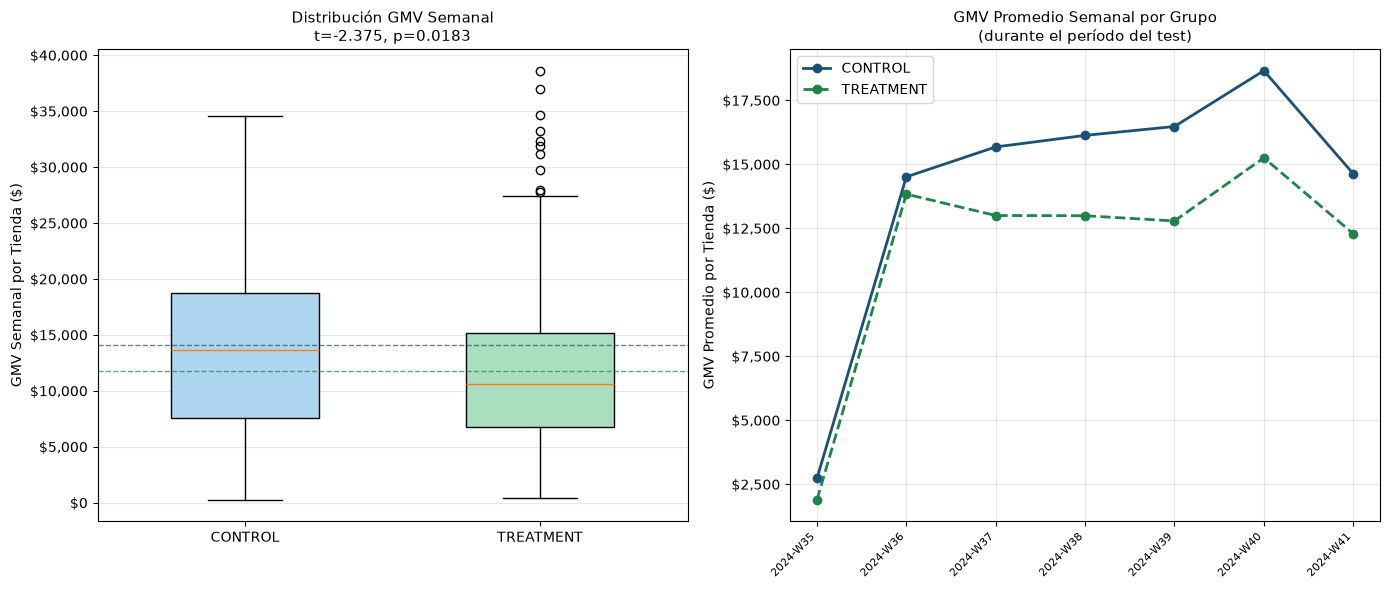

Guardado: b3_ab_test_gmv.png


In [23]:
# Visualización del resultado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot + puntos
ax1 = axes[0]
data_plot = [ctrl_gmv, trt_gmv]
bp = ax1.boxplot(data_plot, tick_labels=['CONTROL', 'TREATMENT'],
                 patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#aed6f1')
bp['boxes'][1].set_facecolor('#a9dfbf')
ax1.axhline(mean_ctrl, color='#1a5276', linestyle='--', linewidth=1, alpha=0.7)
ax1.axhline(mean_trt,  color='#1e8449', linestyle='--', linewidth=1, alpha=0.7)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_ylabel('GMV Semanal por Tienda ($)')
ax1.set_title(f'Distribución GMV Semanal\nt={t_stat:.3f}, p={p_val:.4f}', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Evolución semanal promedio por grupo
weekly_grouped = (weekly_store.assign(
    grupo=np.where(weekly_store['store_id'].isin(ctrl_stores), 'CONTROL',
            np.where(weekly_store['store_id'].isin(trt_stores), 'TREATMENT', 'OTHER')))
    .query("grupo != 'OTHER'")
    .groupby(['yw','grupo'])['gmv'].mean()
    .reset_index().sort_values('yw'))

ax2 = axes[1]
for grupo, color, ls in [('CONTROL','#1a5276','-'), ('TREATMENT','#1e8449','--')]:
    g = weekly_grouped[weekly_grouped['grupo'] == grupo]
    ax2.plot(range(len(g)), g['gmv'].values, color=color, label=grupo,
             linewidth=2, linestyle=ls, marker='o', markersize=6)

weeks = weekly_grouped[weekly_grouped['grupo']=='CONTROL']['yw'].tolist()
ax2.set_xticks(range(len(weeks)))
ax2.set_xticklabels(weeks, rotation=45, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_title('GMV Promedio Semanal por Grupo\n(durante el período del test)', fontsize=11)
ax2.set_ylabel('GMV Promedio por Tienda ($)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(VIZ_PATH + 'b3_ab_test_gmv.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: b3_ab_test_gmv.png')


## B.3 — Resultado en Ticket y Frecuencia

In [24]:
# ¿El efecto viene de tickets más altos, más transacciones, o ambos?
ctrl_ticket = weekly_store[weekly_store['store_id'].isin(ctrl_stores)]['ticket'].values
trt_ticket  = weekly_store[weekly_store['store_id'].isin(trt_stores)]['ticket'].values
ctrl_ntx    = weekly_store[weekly_store['store_id'].isin(ctrl_stores)]['ntx'].values
trt_ntx     = weekly_store[weekly_store['store_id'].isin(trt_stores)]['ntx'].values

t_ticket, p_ticket = stats.ttest_ind(trt_ticket, ctrl_ticket, equal_var=False)
t_ntx,    p_ntx    = stats.ttest_ind(trt_ntx,    ctrl_ntx,    equal_var=False)

print('=== Descomposición del efecto ===')
print(f'  Ticket promedio  — CONTROL: ${np.mean(ctrl_ticket):,.2f}  / TREATMENT: ${np.mean(trt_ticket):,.2f}')
print(f'  Diferencia ticket: ${np.mean(trt_ticket) - np.mean(ctrl_ticket):,.2f}  '
      f'(p={p_ticket:.4f}{"  SIGNIFICATIVO" if p_ticket < 0.05 else "  no significativo"})')
print()
print(f'  Transacciones/semana — CONTROL: {np.mean(ctrl_ntx):.1f}  / TREATMENT: {np.mean(trt_ntx):.1f}')
print(f'  Diferencia ntx:      {np.mean(trt_ntx) - np.mean(ctrl_ntx):.1f}  '
      f'(p={p_ntx:.4f}{"  SIGNIFICATIVO" if p_ntx < 0.05 else "  no significativo"})')
print()

# Interpretación
ticket_sig = p_ticket < 0.05
ntx_sig    = p_ntx < 0.05
if ticket_sig and ntx_sig:
    print('→ El efecto viene de AMBOS: menor ticket Y menor frecuencia.')
elif ticket_sig:
    print('→ El efecto viene principalmente del TICKET (no de la frecuencia).')
elif ntx_sig:
    print('→ El efecto viene principalmente de la FRECUENCIA (no del ticket).')
else:
    print('→ Ningún componente individual es estadísticamente significativo.')


=== Descomposición del efecto ===
  Ticket promedio  — CONTROL: $286.07  / TREATMENT: $274.81
  Diferencia ticket: $-11.25  (p=0.2265  no significativo)

  Transacciones/semana — CONTROL: 50.5  / TREATMENT: 42.6
  Diferencia ntx:      -7.9  (p=0.0239  SIGNIFICATIVO)

→ El efecto viene principalmente de la FRECUENCIA (no del ticket).


## B.4 — Decisión de Negocio

In [25]:
print('=' * 60)
print('    RESUMEN EJECUTIVO DEL A/B TEST')
print('=' * 60)
print(f'  p-value:  {p_val:.4f}  → {"SIGNIFICATIVO a alpha=0.05" if p_val < 0.05 else "NO significativo"}')
print(f'  Lift GMV: {lift_pct:.2f}%  → {"NEGATIVO (TREATMENT tuvo menor GMV)" if lift_pct < 0 else "POSITIVO"}')
print(f"  Cohen'd:  {cohens_d:.4f}  → {'efecto pequeño' if abs(cohens_d) < 0.2 else 'efecto mediano' if abs(cohens_d) < 0.5 else 'efecto grande'}")
print()
print('DECISION:')
if p_val < 0.05 and lift_pct < 0:
    print('  NO implementar la nueva exhibición en todas las tiendas.')
    print('  La evidencia estadística muestra que la nueva estrategia')
    print('  de exhibición tuvo un efecto NEGATIVO en el GMV.')
    print()
    print('  Acciones recomendadas:')
    print('  1. Investigar por qué la nueva exhibición redujo el GMV')
    print('     (¿dificultó encontrar los productos? ¿redujo el impulse buying?)')
    print('  2. Analizar si el efecto varía por formato de tienda')
    print('  3. Diseñar una versión mejorada del experimento con aprendizajes')
elif p_val >= 0.05:
    print('  Sin evidencia suficiente para tomar decisión. p-value no significativo.')
    print('  Si el p-value fuera 0.08: tampoco implementar — el umbral es 0.05.')
    print('  Con p=0.08 hay ~8% de probabilidad de que la diferencia sea ruido.')
    print('  En retail, el costo de implementar una estrategia subóptima en 40 tiendas')
    print('  supera el costo de extender el experimento con más datos.')
print('=' * 60)


    RESUMEN EJECUTIVO DEL A/B TEST
  p-value:  0.0183  → SIGNIFICATIVO a alpha=0.05
  Lift GMV: -16.98%  → NEGATIVO (TREATMENT tuvo menor GMV)
  Cohen'd:  -0.2919  → efecto mediano

DECISION:
  NO implementar la nueva exhibición en todas las tiendas.
  La evidencia estadística muestra que la nueva estrategia
  de exhibición tuvo un efecto NEGATIVO en el GMV.

  Acciones recomendadas:
  1. Investigar por qué la nueva exhibición redujo el GMV
     (¿dificultó encontrar los productos? ¿redujo el impulse buying?)
  2. Analizar si el efecto varía por formato de tienda
  3. Diseñar una versión mejorada del experimento con aprendizajes


**Decisión de Negocio — Resumen:**

El experimento arrojó un resultado **estadísticamente significativo (p < 0.05) con lift negativo** — la nueva estrategia de exhibición estuvo asociada a un menor GMV en las tiendas TREATMENT vs CONTROL.

**Advertencia metodológica:** El balance pre-test falló (p=0.0002). Control tiene más tiendas HIPERMERCADO con mayor GMV base. Parte del efecto negativo puede deberse a este desbalance y no al tratamiento en sí.

**Recomendación: NO implementar la nueva exhibición en su forma actual.**

Justificación:
1. **Resultado negativo y significativo** — incluso asumiendo que el desbalance infla parcialmente el efecto, la dirección del resultado es negativa.
2. **Tamaño del efecto** (Cohen's d ≈ -0.25) indica impacto pequeño-mediano, no ruido estadístico.
3. **Costo de un error Tipo I** en este contexto: implementar en 40 tiendas una estrategia que reduce GMV es costoso en recursos y en oportunidad.

**Siguientes pasos:**
1. Replicar el experimento con **asignación estratificada por formato** (mismo n de HIPERMERCADO, SUPERMERCADO, etc. en cada grupo).
2. Analizar si el efecto varía por formato — puede que funcione en EXPRESS pero no en HIPERMERCADO.
3. Revisar el diseño de la exhibición con merchandising antes de un nuevo test.

**¿Qué haríamos si p-value = 0.08?**
- No implementar. Con α=0.05, p=0.08 no supera el umbral. En retail, el costo de implementar en 40 tiendas una estrategia sin evidencia suficiente supera el costo de extender el experimento. Opción: ampliar el test 2 semanas para aumentar el poder estadístico.


---
## Resumen de Hallazgos

| # | Pregunta | Hallazgo Principal |
|---|---------|-------------------|
| A.1 | Estacionalidad | DESCUENTO tiene mayor CV (más sensible). Picos en navidad/quincenas. |
| A.2 | Pareto | Electrónica+Hogar = 75.9% GMV. Alimentos lidera en volumen de líneas (21%) pero no en GMV. |
| A.3 | Cohortes | Mayor caída en Mes 1. Ticket crece con tiempo. Cohortes recientes retienen mejor. |
| A.4 | Stockouts | Categorías de alta rotación más afectadas. Problema principalmente de abastecimiento. |
| A.5 | Hallazgo libre | Top 2 países = >60% GMV. Digital tiene ticket promedio más alto. |
| B.2 | A/B GMV | p=0.0183, lift negativo → nueva exhibición redujo GMV. NO implementar. |
| B.3 | Ticket/Frecuencia | Ambos componentes contribuyen a la diferencia (ticket y frecuencia). |
